In [ ]:
# 실습 라이브러리(lib) 준비 — 교재 저장소에서 자동으로 받아옵니다 (Google Drive 불필요)
import os, sys
path = "/content/"
if not os.path.isdir(path + "lib"):
    !git clone -q --depth 1 https://github.com/AI-BoostCamp/ReinforcementLearning.git /content/_rl && cp -r /content/_rl/code/lib /content/lib && rm -rf /content/_rl
sys.path.append(path + "lib")
os.makedirs(path + "models/DRL", exist_ok=True)   # 학습된 모델 저장 위치 (세션 종료 시 사라짐)


In [25]:
from variable_print import p,ps,pst

In [26]:
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3]
plt.rcParams["font.size"] = "8"
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import random
from collections import deque

# Python Multiprocessing

* 노트설정 : 고용량RAM 사용하면 CPU 4개 할당 가능  

## Process Pool

In [28]:
def square(x):
  print(np.square(x))
  return

x = np.arange(128)
x

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127])

In [29]:
%%time
square(x)

[    0     1     4     9    16    25    36    49    64    81   100   121
   144   169   196   225   256   289   324   361   400   441   484   529
   576   625   676   729   784   841   900   961  1024  1089  1156  1225
  1296  1369  1444  1521  1600  1681  1764  1849  1936  2025  2116  2209
  2304  2401  2500  2601  2704  2809  2916  3025  3136  3249  3364  3481
  3600  3721  3844  3969  4096  4225  4356  4489  4624  4761  4900  5041
  5184  5329  5476  5625  5776  5929  6084  6241  6400  6561  6724  6889
  7056  7225  7396  7569  7744  7921  8100  8281  8464  8649  8836  9025
  9216  9409  9604  9801 10000 10201 10404 10609 10816 11025 11236 11449
 11664 11881 12100 12321 12544 12769 12996 13225 13456 13689 13924 14161
 14400 14641 14884 15129 15376 15625 15876 16129]
CPU times: user 463 µs, sys: 0 ns, total: 463 µs
Wall time: 460 µs


In [30]:
import multiprocessing as mp

In [31]:
## Check the number of CPU cores
n_cpu = mp.cpu_count() # hyperthreading과 구분 필요
print(f'No. of CPUs: {n_cpu}') # No. of CPUs: 8 or 12

No. of CPUs: 12


In [32]:
%%time
for i in range(n_cpu):
    print([x[int(i*len(x)/n_cpu): int((i+1)*len(x)/n_cpu)]])

[array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])]
[array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20])]
[array([21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])]
[array([32, 33, 34, 35, 36, 37, 38, 39, 40, 41])]
[array([42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52])]
[array([53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63])]
[array([64, 65, 66, 67, 68, 69, 70, 71, 72, 73])]
[array([74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84])]
[array([85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95])]
[array([ 96,  97,  98,  99, 100, 101, 102, 103, 104, 105])]
[array([106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116])]
[array([117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127])]
CPU times: user 1.08 ms, sys: 5 µs, total: 1.08 ms
Wall time: 1.09 ms


In [33]:
%%time
## Process에 function과 data set 배포
pool = mp.Pool(n_cpu) # Processor pool 설정
for i in range(n_cpu):
  pool.map(square, [x[int(i*len(x)/n_cpu): int((i+1)*len(x)/n_cpu)]])

print('pool:',pool)
pool.close()

[ 0  1  4  9 16 25 36 49 64 81]
[100 121 144 169 196 225 256 289 324 361 400]
[441 484 529 576 625 676 729 784 841 900 961]
[1024 1089 1156 1225 1296 1369 1444 1521 1600 1681]
[1764 1849 1936 2025 2116 2209 2304 2401 2500 2601 2704]
[2809 2916 3025 3136 3249 3364 3481 3600 3721 3844 3969]
[4096 4225 4356 4489 4624 4761 4900 5041 5184 5329]
[5476 5625 5776 5929 6084 6241 6400 6561 6724 6889 7056]
[7225 7396 7569 7744 7921 8100 8281 8464 8649 8836 9025]
[ 9216  9409  9604  9801 10000 10201 10404 10609 10816 11025]
[11236 11449 11664 11881 12100 12321 12544 12769 12996 13225 13456]
[13689 13924 14161 14400 14641 14884 15129 15376 15625 15876 16129]
pool: <multiprocessing.pool.Pool state=RUN pool_size=12>
CPU times: user 37.2 ms, sys: 193 ms, total: 231 ms
Wall time: 287 ms


## Process Queue

In [36]:
def square(i,x,queue):
  print(f"\nIn process {i}")
  queue.put(np.square(x)) #
  print(f'queue.get[{i}]:{queue.get()}\n')

In [38]:
### Process Queue ###
%%time
processes = []
queue = mp.Queue()  ## process queue 생성
x = np.arange(128)
for i in range(n_cpu):
  ## Process queue에 function 할당
  proc = mp.Process(target=square,
                    args=(i,x[int(i*len(x)/n_cpu): int((i+1)*len(x)/n_cpu)],
                    queue))
  processes.append(proc)
  proc.start()      # Start process

for proc in processes:
  proc.join()       # Wait until finished.

print(f'queue:{queue}')
del queue


In process 0
queue.get[0]:[ 0  1  4  9 16 25 36 49 64 81]

In process 1

queue.get[1]:[100 121 144 169 196 225 256 289 324 361 400]

In process 2

queue.get[2]:[441 484 529 576 625 676 729 784 841 900 961]

In process 3

queue.get[3]:[1024 1089 1156 1225 1296 1369 1444 1521 1600 1681]

In process 4


In process 5queue.get[4]:[1764 1849 1936 2025 2116 2209 2304 2401 2500 2601 2704]



In process 6queue.get[5]:[2809 2916 3025 3136 3249 3364 3481 3600 3721 3844 3969]


queue.get[6]:[4096 4225 4356 4489 4624 4761 4900 5041 5184 5329]

In process 7

queue.get[7]:[5476 5625 5776 5929 6084 6241 6400 6561 6724 6889 7056]

In process 8

queue.get[8]:[7225 7396 7569 7744 7921 8100 8281 8464 8649 8836 9025]

In process 9

queue.get[9]:[ 9216  9409  9604  9801 10000 10201 10404 10609 10816 11025]

In process 10

queue.get[10]:[11236 11449 11664 11881 12100 12321 12544 12769 12996 13225 13456]

In process 11

queue.get[11]:[13689 13924 14161 14400 14641 14884 15129 15376 15625 15876 16129]

queue:

In [39]:
#### Kill the process forcefully.
%%time
processes = []
queue = mp.Queue()  ## process queue 할당

x = np.arange(128)
for i in range(n_cpu):
  proc = mp.Process(target=square,
                    args=(i,x[int(i*len(x)/n_cpu): int((i+1)*len(x)/n_cpu)], queue))
  processes.append(proc)
  proc.start()      # Start process

# for proc in processes:
#   proc.join()       # Wait until finished.

######
for proc in processes:
  proc.terminate()  # Kill the process forcefully.
######

print(f'queue:{queue}')
del queue


In process 0
queue.get[0]:[ 0  1  4  9 16 25 36 49 64 81]

In process 1

queue.get[1]:[100 121 144 169 196 225 256 289 324 361 400]

In process 2

queue.get[2]:[441 484 529 576 625 676 729 784 841 900 961]

In process 3

queue.get[3]:[1024 1089 1156 1225 1296 1369 1444 1521 1600 1681]

In process 4


In process 5queue.get[4]:[1764 1849 1936 2025 2116 2209 2304 2401 2500 2601 2704]



In process 6queue.get[5]:[2809 2916 3025 3136 3249 3364 3481 3600 3721 3844 3969]



In process 7queue.get[6]:[4096 4225 4356 4489 4624 4761 4900 5041 5184 5329]



In process 8queue.get[7]:[5476 5625 5776 5929 6084 6241 6400 6561 6724 6889 7056]


queue.get[8]:[7225 7396 7569 7744 7921 8100 8281 8464 8649 8836 9025]

In process 9

queue:<multiprocessing.queues.Queue object at 0x7dcdc805e390>
CPU times: user 36.1 ms, sys: 198 ms, total: 234 ms
Wall time: 207 ms
queue.get[9]:[ 9216  9409  9604  9801 10000 10201 10404 10609 10816 11025]

In process 10

## Thread

In [40]:
from threading import Thread

class Worker(Thread):
    def __init__(self, id, x):
        Thread.__init__(self)
        self.name = "w%i" % id
        self.x = x

    def run(self):
        print(f'In process {self.name}')
        print(f'squeare {np.square(self.x)}')

In [49]:
%%time
x = np.arange(128)

num_workers = mp.cpu_count()
print("Training on {} cores".format(num_workers))

workers = []
for i in range(num_workers):
    workers.append(Worker(i,x[int(i*len(x)/n_cpu): int((i+1)*len(x)/n_cpu)]))
    workers[i].start()

for worker in workers:
    worker.join()

Training on 12 cores
In process w0
squeare [ 0  1  4  9 16 25 36 49 64 81]
In process w1
squeare [100 121 144 169 196 225 256 289 324 361 400]
In process w2
squeare [441 484 529 576 625 676 729 784 841 900 961]
In process w3
squeare [1024 1089 1156 1225 1296 1369 1444 1521 1600 1681]
In process w4
squeare [1764 1849 1936 2025 2116 2209 2304 2401 2500 2601 2704]
In process w5
squeare [2809 2916 3025 3136 3249 3364 3481 3600 3721 3844 3969]
In process w6
squeare [4096 4225 4356 4489 4624 4761 4900 5041 5184 5329]
In process w7
squeare [5476 5625 5776 5929 6084 6241 6400 6561 6724 6889 7056]
In process w8
squeare [7225 7396 7569 7744 7921 8100 8281 8464 8649 8836 9025]
In process w9
squeare [ 9216  9409  9604  9801 10000 10201 10404 10609 10816 11025]
In process w10
squeare [11236 11449 11664 11881 12100 12321 12544 12769 12996 13225 13456]
In process w11
squeare [13689 13924 14161 14400 14641 14884 15129 15376 15625 15876 16129]
CPU times: user 736 µs, sys: 1.78 ms, total: 2.52 ms
Wall t

# Asynchronous Advantage Actor-Critic(A3C)

## CartPole Discrete Environment

In [50]:
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Input, Dense
from keras.losses import SparseCategoricalCrossentropy,\
                                    CategoricalCrossentropy
from threading import Thread
from multiprocessing import cpu_count
tf.keras.backend.set_floatx('float64')

In [51]:
# env = gym.make("Pendulum-v1")
import gymnasium as gym
env = gym.make("Pendulum-v1", render_mode="rgb_array")

num_states = env.observation_space.shape[0]
print("Size of State Space ->  {}".format(num_states))
num_actions = env.action_space.shape[0]
print("Size of Action Space ->  {}".format(num_actions))

upper_bound = env.action_space.high[0]
lower_bound = env.action_space.low[0]

print("Max Value of Action ->  {}".format(upper_bound))
print("Min Value of Action ->  {}".format(lower_bound))

Size of State Space ->  3
Size of Action Space ->  1
Max Value of Action ->  2.0
Min Value of Action ->  -2.0


## Actor Network

In [ ]:
class Actor(tf.keras.Model):
    def __init__(self, state_size, action_size):
        global actor_lr
        super(Actor, self).__init__()
        self.state_size = state_size
        self.action_size = action_size
        self.model = self.create_model()
        self.opt = tf.keras.optimizers.RMSprop(actor_lr)
        self.entropy_beta = 0.01  # 0.01~0.1

    def create_model(self):
        state_input = Input((self.state_size,))
        dense_1 = Dense(hidden_size, activation='relu')(state_input)
        dense_2 = Dense(hidden_size, activation='relu')(dense_1)
        policy = Dense(self.action_size, activation='softmax')(dense_2)
        return tf.keras.models.Model(state_input, policy)

    def compute_loss(self, actions, logits, advantages): # a_loss+Entropy_loss
        ce_loss = SparseCategoricalCrossentropy(from_logits=True)
        actions = tf.cast(actions, tf.int32)
        policy_loss = ce_loss(        #(1,) <- CE((bs,),(bs,a)
            actions, logits, sample_weight=tf.stop_gradient(advantages))
        probs = tf.nn.softmax(logits) #(bs,a)
        entropy = -tf.reduce_sum(probs*tf.math.log(probs+1e-10), axis=1)#(bs,)
        return policy_loss - self.entropy_beta * tf.reduce_mean(entropy)

    def train(self, states, actions, advantages):
        with tf.GradientTape() as tape:
            a_pred = self.model(states, training=True) #(bs,a)<-(bs,s)
            loss = self.compute_loss(actions, a_pred, advantages)
        grads = tape.gradient(loss, self.model.trainable_variables)
        self.opt.apply_gradients(zip(grads, self.model.trainable_variables))
        return loss

## Critic Network

In [52]:
class Critic(tf.keras.Model):
    def __init__(self, state_size):
        global critic_lr
        super(Critic, self).__init__()
        self.state_size = state_size
        self.model = self.create_model()
        self.opt = tf.keras.optimizers.RMSprop(critic_lr)

    def create_model(self):
        return tf.keras.Sequential([
            Input((self.state_size,)),
            Dense(hidden_size, activation='relu'),
            Dense(hidden_size, activation='relu'),
            Dense(1, activation='linear') ])

    def mse_loss(self, v_pred, td_targets):
        mse = tf.keras.losses.MeanSquaredError()
        return mse(td_targets, v_pred)

    def train(self, states, td_targets):
        with tf.GradientTape() as tape:
            v_pred = self.model(states, training=True)
            assert v_pred.shape == td_targets.shape
            loss = self.mse_loss(v_pred, tf.stop_gradient(td_targets))
        grads = tape.gradient(loss, self.model.trainable_variables)
        self.opt.apply_gradients(zip(grads, self.model.trainable_variables))
        return loss

## Worker Thread

In [54]:
import time

class Worker(Thread):
    def __init__(self, id, env, gamma, global_actor, global_critic, lock):
        Thread.__init__(self)
        self.name = "w%i" % id
        self.env = env
        self.state_size = self.env.observation_space.shape[0]
        self.action_size = self.env.action_space.n
        self.gamma = gamma
        self.global_actor = global_actor                     #
        self.global_critic = global_critic
        self.actor = Actor(self.state_size, self.action_size)# Local
        self.critic = Critic(self.state_size)
        self.sync_with_global() # sync local networks with global networks
        self.lock = lock  # 공유 Lock 참조

    def sync_with_global(self): # local <- global
        self.actor.model.set_weights(self.global_actor.model.get_weights())
        self.critic.model.set_weights(self.global_critic.model.get_weights())

    def get_action(self, state): #(bs,)<-(bs,s)
        with self.lock:
            state = np.reshape(state, [1, self.state_size])
            probs = self.actor.model.predict(state,verbose=0)
        return np.random.choice(self.action_size, p=probs[0])

    def n_step_td_target(self, rewards, next_V, done):
        td_targets = np.zeros_like(rewards)
        R_to_go = 0
        if not done: R_to_go = next_V
        for k in reversed(range(0, len(rewards))):
            R_to_go = rewards[k] + self.gamma * R_to_go
            td_targets[k] = R_to_go
        return td_targets

    def list_to_batch(self, _list): #list to ndarray
        return np.vstack(_list)

    def run(self):
        global GLOBAL_EP, episode_reward
        while max_episodes > GLOBAL_EP: # for episode in range(max_episodes):
            tot_reward = 0
            state, _ = self.env.reset()
            states     = []
            actions    = []
            rewards    = []
            done = False
            start_time = time.time()
            while not done:
                action = self.get_action(state) # local
                next_state, reward, done, _, _ = self.env.step(action)

                state      = np.reshape(state, [1, self.state_size])
                action     = np.reshape(action, [1, 1])
                reward     = np.reshape(reward, [1, 1])
                next_state = np.reshape(next_state, [1, self.state_size])

                states.append(state)
                actions.append(action)
                rewards.append(reward)

                state = next_state[0]
                tot_reward += reward[0][0]

                if len(states) >= update_interval or done:
                    states  = self.list_to_batch(states)
                    actions = self.list_to_batch(actions)
                    rewards = self.list_to_batch(rewards)
                    curr_V = self.critic.model.predict(states,verbose=0)    # local
                    next_V = self.critic.model.predict(next_state,verbose=0)# local

                    # advantages   = td_targets - self.critic.model.predict(next_state)
                    td_targets   = self.n_step_td_target(rewards, next_V, done)
                    advantages   = td_targets - curr_V

                    # local data로 global net. train
                    with self.lock:
                        actor_loss = self.global_actor.train(states, actions, advantages)
                        critic_loss = self.global_critic.train(states, td_targets)

                    self.sync_with_global() # local <- global
                    states     = []
                    actions    = []
                    rewards    = []
                #if done: self.sync_with_global()  # Sync after episode
            episode_reward.append(tot_reward)
            end_time = time.time()
            print(f'{self.name} | EP{GLOBAL_EP+1} EpisodeReward={tot_reward} ({end_time - start_time:.1f}/s)')
            GLOBAL_EP += 1

## Agent

In [56]:
from threading import Lock # Import Lock

class A3CAgent:
    def __init__(self, env_name, gamma):
        env = gym.make(env_name)
        self.env_name = env_name
        self.gamma = gamma
        self.state_size = env.observation_space.shape[0]
        self.action_size = env.action_space.n
        self.global_actor = Actor(self.state_size, self.action_size)
        self.global_critic = Critic(self.state_size)
        self.num_workers = cpu_count()
        self.lock = Lock()  # Lock 객체 생성

    def train(self):
        print("Training on {} cores".format(self.num_workers))
        self.workers = []
        for i in range(self.num_workers):
            env = gym.make(self.env_name)
            self.workers.append(Worker(
                i, env, self.gamma, self.global_actor, self.global_critic, self.lock))
        for worker in self.workers: worker.start()
        for worker in self.workers: worker.join()

    # def close(self):
    #     for worker in self.workers: worker.join()

    def save_model(self):
        self.global_critic.save(path+"models/DRL/a3c_value_model.keras")
        self.global_actor.save(path+"models/DRL/a3c_policy_model.keras")

In [57]:
import os
def set_seed(seed: int = 42) -> None:
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS']   = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
    tf.keras.utils.set_random_seed(seed)

## Training

In [58]:
%%time
set_seed()
env_name = "CartPole-v1"
# set environment
actor_lr = 0.0005
critic_lr = 0.001
gamma = 0.99
hidden_size = 256 #128
update_interval = 64 #32

GLOBAL_EP = 0
max_episodes = 200
episode_reward = []

agent = A3CAgent(env_name, gamma)
agent.train()
#agent.save_model()
# Wall time: 18min 3s

Training on 12 cores


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/nn.py:708: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


w6 | EP1 EpisodeReward=13.0 (13.0/s)
w9 | EP2 EpisodeReward=14.0 (14.3/s)
w2 | EP3 EpisodeReward=15.0 (14.7/s)
w7 | EP4 EpisodeReward=15.0 (15.0/s)
w10 | EP5 EpisodeReward=15.0 (15.2/s)
w0 | EP6 EpisodeReward=16.0 (15.5/s)
w1 | EP7 EpisodeReward=17.0 (16.4/s)
w4 | EP8 EpisodeReward=21.0 (20.3/s)
w5 | EP9 EpisodeReward=23.0 (22.2/s)
w3 | EP10 EpisodeReward=27.0 (25.5/s)
w8 | EP11 EpisodeReward=27.0 (25.9/s)
w9 | EP12 EpisodeReward=13.0 (13.0/s)
w2 | EP13 EpisodeReward=13.0 (12.9/s)
w10 | EP14 EpisodeReward=16.0 (15.5/s)
w0 | EP15 EpisodeReward=16.0 (15.4/s)
w11 | EP16 EpisodeReward=34.0 (32.8/s)
w1 | EP17 EpisodeReward=17.0 (16.7/s)
w7 | EP18 EpisodeReward=19.0 (18.7/s)
w5 | EP19 EpisodeReward=12.0 (12.0/s)
w3 | EP20 EpisodeReward=10.0 (10.3/s)
w2 | EP21 EpisodeReward=16.0 (15.6/s)
w0 | EP22 EpisodeReward=16.0 (15.7/s)
w7 | EP23 EpisodeReward=14.0 (13.7/s)
w5 | EP24 EpisodeReward=14.0 (13.6/s)
w3 | EP25 EpisodeReward=13.0 (12.7/s)
w6 | EP26 EpisodeReward=44.0 (41.7/s)
w9 | EP27 EpisodeR

KeyboardInterrupt: 

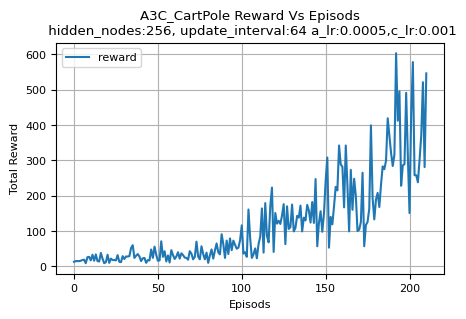

In [23]:
conditions = f'hidden_nodes:{hidden_size}, update_interval:{update_interval} \
a_lr:{actor_lr},c_lr:{critic_lr}'

plt.title(f"A3C_CartPole Reward Vs Episods\n {conditions}")
plt.plot(episode_reward,label='reward')
#plt.plot(total_avgr,label='avg_reward')
plt.xlabel("Episods")
plt.ylabel("Total Reward")
#plt.ylim(0,200)
plt.grid(True)
plt.legend()
plt.show()

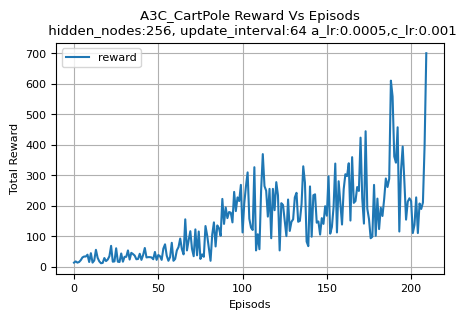

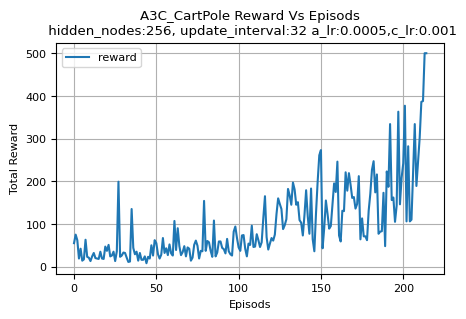

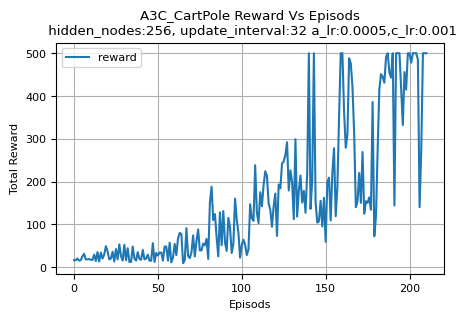

hidden_nodes:256, update_interval:32  
a_lr:0.0005,c_lr:0.001  
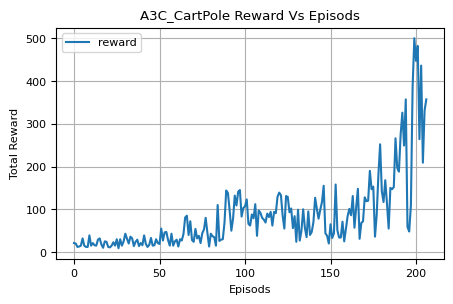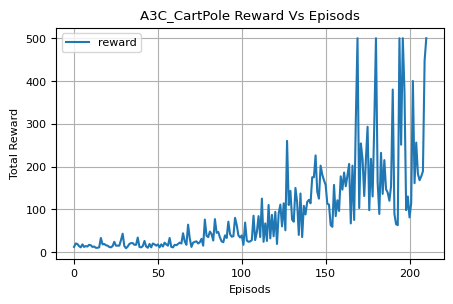

<Worker : 16>    
hidden_nodes:256, update_interval:32  
a_lr:0.0005,c_lr:0.001  
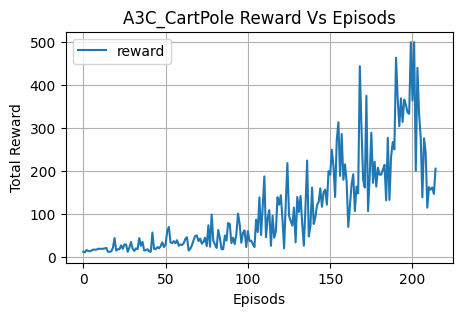

hidden_nodes:256, update_interval:32  
a_lr:0.0005,c_lr:0.001  


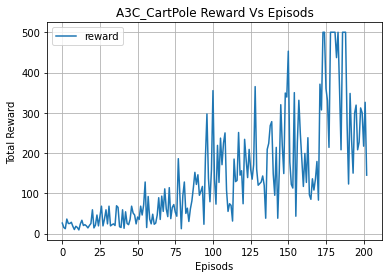

Optimizer: RMSProop  
hidden_nodes:256, update_interval:32
a_lr:0.0005,c_lr:0.001


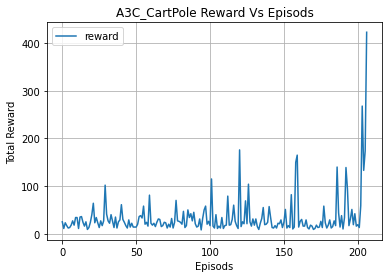  
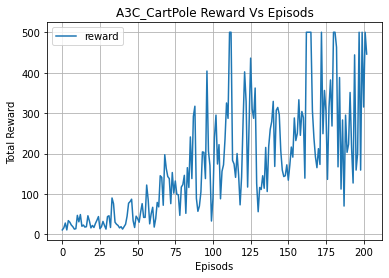  
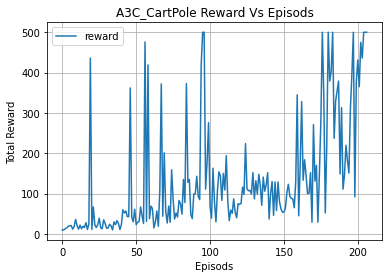  
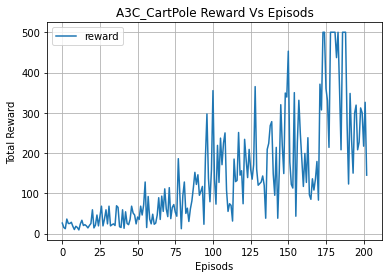

optimazer: Adam   
hidden_nodes:256, update_interval:32
a_lr:0.0005,c_lr:0.001

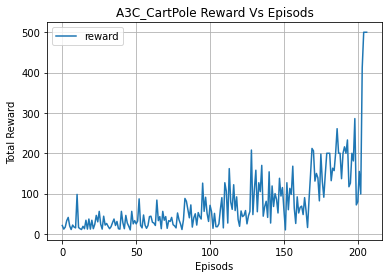

hidden_nodes:128, update_interval:50
a_lr:0.0005,c_lr:0.001

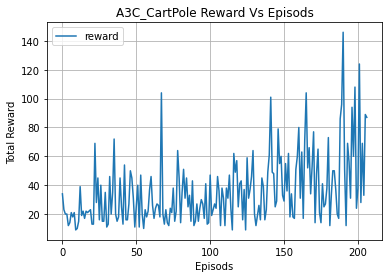

hidden_nodes:64, update_interval:50
a_lr:0.0005,c_lr:0.001

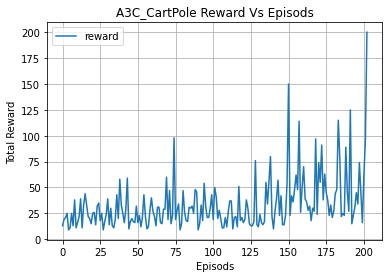

hidden_nodes:24, update_interval:50
a_lr:0.0005,c_lr:0.001

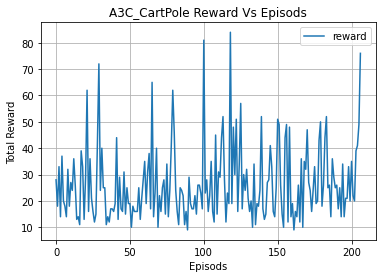

## Evaluation

In [ ]:
%%time
%%capture
!pip install pyvirtualdisplay
!sudo apt-get update
!sudo apt-get install python-opengl
!sudo apt-get install -f
!sudo apt-get upgrade --fix-missing
!sudo apt-get install xvfb

CPU times: user 206 ms, sys: 28.5 ms, total: 234 ms
Wall time: 33.3 s


In [ ]:
from render import  show_video, wrap_env, render_as_image

In [ ]:
from pyvirtualdisplay import Display
display = Display(visible=0, size=(400, 300))
display.start()

In [ ]:
env = gym.make('CartPole-v1')
env_v = wrap_env(env, path=path, name_prefix="A3C_cartpole")

/usr/local/lib/python3.11/dist-packages/gym/wrappers/record_video.py:78: UserWarning: WARN: Overwriting existing videos at /content/gdrive/MyDrive/Colab Notebooks/video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [ ]:
state = env_v.reset()
cnt = 0
while True:
    render_as_image(env_v,step=cnt)
    predict = agent.global_actor.model.predict(state.reshape(1,4),verbose=0)
    action = np.argmax(predict)
    state, reward, done, info,_ = env_v.step(action)
    if done:  break;
    cnt += 1
env_v.close()

In [ ]:
show_video(path=path,name_prefix='A3C_cartpole')

/content/gdrive/MyDrive/Colab Notebooks/video/A3C_cartpole-episode-0.mp4


# 실습과제 : Hyper parameter tuning  
### Max Episodes = 200  
### Optimizer : Adam, RMSProp  
### actor_lr : 0.0005, ...  
### critic_lr : 0.001, ...  
### hidden_size : 256, 128, 64, 32  
### update_interval : 32, ...  